### Import

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocess

In [3]:
train_df = pd.read_csv("/train.csv")
test_df = pd.read_csv("/test.csv")

In [4]:
# 결측치 비율 3% 넘는 열 삭제(train)
threshold = 0.03
missing_ratio = train_df.isnull().sum() / len(train_df)
columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
train_df_cleaned = train_df.drop(columns=columns_to_drop)
columns_to_drop

['임신 시도 또는 마지막 임신 경과 연수',
 '착상 전 유전 검사 사용 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일',
 '배아 해동 경과일']

In [5]:
# 결측치 비율 3% 넘는 열 삭제(test)
missing_ratio = test_df.isnull().sum() / len(test_df)
columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
test_df_cleaned = test_df.drop(columns=columns_to_drop)
columns_to_drop

['임신 시도 또는 마지막 임신 경과 연수',
 '착상 전 유전 검사 사용 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일',
 '배아 해동 경과일']

In [11]:
missing_values = train_df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

,0
해동된 배아 수,6291
단일 배아 이식 여부,6291
기증 배아 사용 여부,6291
신선 배아 사용 여부,6291
동결 배아 사용 여부,6291
기증자 정자와 혼합된 난자 수,6291
파트너 정자와 혼합된 난자 수,6291
혼합된 난자 수,6291
저장된 신선 난자 수,6291
수집된 신선 난자 수,6291


In [7]:
missing_values = test_df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

,0
단일 배아 이식 여부,2176
해동 난자 수,2176
기증 배아 사용 여부,2176
신선 배아 사용 여부,2176
동결 배아 사용 여부,2176
기증자 정자와 혼합된 난자 수,2176
파트너 정자와 혼합된 난자 수,2176
혼합된 난자 수,2176
저장된 신선 난자 수,2176
수집된 신선 난자 수,2176


In [8]:
di_count = train_df[train_df['시술 유형'] == 'DI'].shape[0]
di_count

6291

In [9]:
di_count = test_df[test_df['시술 유형'] == 'DI'].shape[0]
di_count

2176

In [12]:
# 결측치 있는 특성 가져오기
categorical_cols = test_df_cleaned.select_dtypes(include=['object']).columns
numerical_cols = train_df_cleaned.select_dtypes(include=['float64', 'int64']).columns

missing_columns = missing_values.index.tolist()
missing_num = [col for col in missing_columns if col in numerical_cols]
missing_cat = [col for col in missing_columns if col in categorical_cols]
print('num:', missing_num)
print('cat:', missing_cat)

num: ['해동된 배아 수', '단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '대리모 여부', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수', '총 생성 배아 수', '착상 전 유전 진단 사용 여부']
cat: ['배아 생성 주요 이유', '특정 시술 유형']


#### numerical 결측치 처리

In [13]:
# 알 수 없는 열은 -1(train)
missing_num_what = ['기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '총 생성 배아 수']
train_df_cleaned[missing_num_what] = train_df_cleaned[missing_num_what].fillna(-1)
# DI이므로 무조건 0인 열(train)
missing_num_zero = ['해동된 배아 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수','단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '대리모 여부']
train_df_cleaned[missing_num_zero] = train_df_cleaned[missing_num_zero].fillna(0)

In [14]:
# 알 수 없는 열은 -1(test)
missing_num_what = ['기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '총 생성 배아 수']
test_df_cleaned[missing_num_what] = test_df_cleaned[missing_num_what].fillna(-1)
# DI이므로 무조건 0인 열(test)
missing_num_zero = ['해동된 배아 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수', '단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '대리모 여부']
test_df_cleaned[missing_num_zero] = test_df_cleaned[missing_num_zero].fillna(0)

#### categorical 결측치 처리

In [15]:
# 알 수 없음
train_df_cleaned = train_df_cleaned.drop(columns=['착상 전 유전 진단 사용 여부'])
train_df_cleaned['배아 생성 주요 이유'] = train_df_cleaned['배아 생성 주요 이유'].fillna('관련없음')
train_df_cleaned['특정 시술 유형'] = train_df_cleaned['특정 시술 유형'].fillna('Unknown')

In [16]:
# (test)
test_df_cleaned = test_df_cleaned.drop(columns=['착상 전 유전 진단 사용 여부'])
test_df_cleaned['배아 생성 주요 이유'] = test_df_cleaned['배아 생성 주요 이유'].fillna('관련없음')

### 결측치 시각화

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

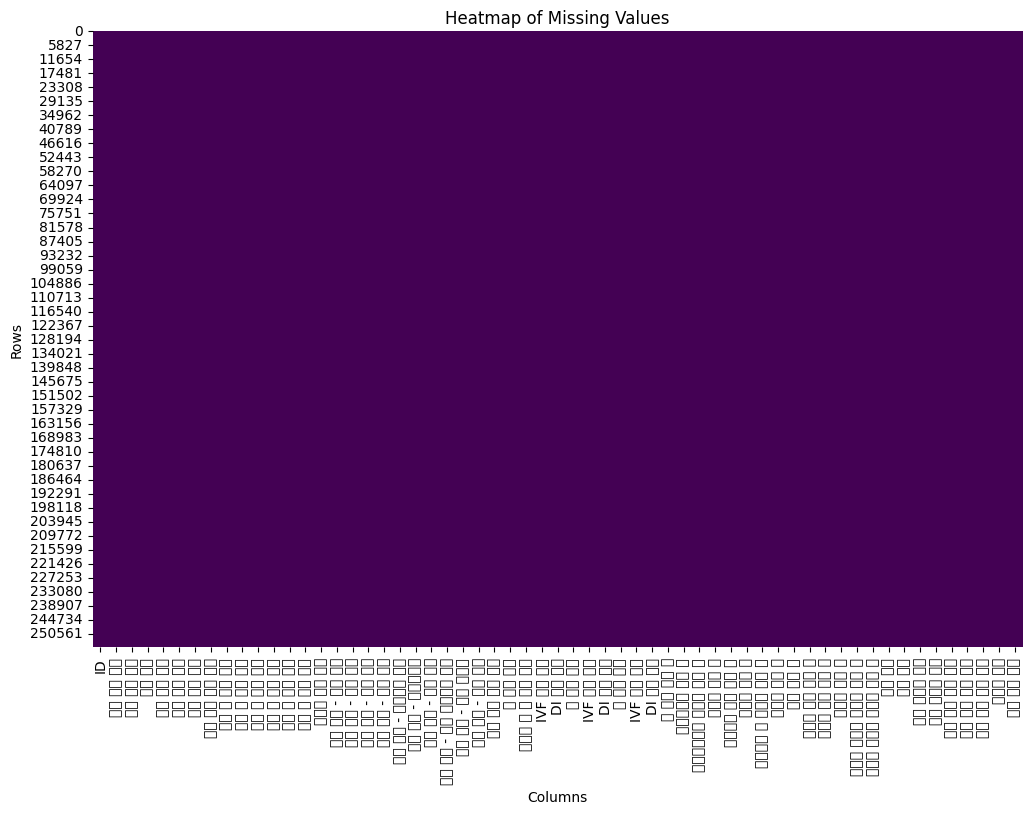

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

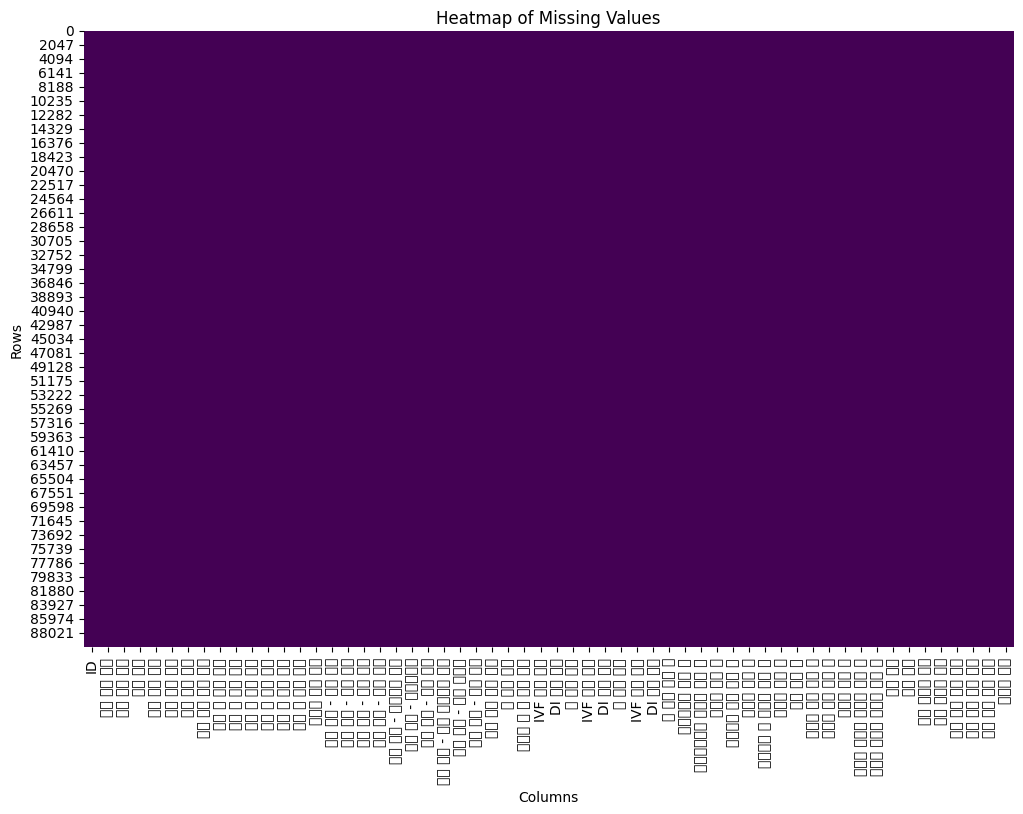

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(test_df_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 저장

In [19]:
train_df_cleaned.to_csv('train_cleaned.csv', index=False, encoding='utf-8-sig')

In [20]:
test_df_cleaned.to_csv('test_cleaned.csv', index=False, encoding='utf-8-sig')